## Problem Statement


You are a data scientist at a management consulting firm specializing in workplace efficiency and employee productivity. You have been provided with a dataset named **"employees_work_hours_data.csv"**, containing detailed records of employees’ work hours and related attributes in a corporate setting. The dataset includes the following columns:

- **employee_id:** A unique identifier for each employee.
- **department:** The department where the employee works (e.g., Sales, IT, HR).
- **remote_working:** Indicates whether the employee is working remotely (Yes/No).
- **hours_worked_per_day:** The average number of hours the employee works per day.

**Import Necessary Libraries**

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Task1: Importing and Examining the Dataset

1. Import the data from the "employees_work_hours_data.csv" file.
2. display the number of rows and columns. 
3. Display the first few rows of the dataset to get an overview.


In [2]:
df = pd.read_csv('employees_work_hours_data.csv')
print(df.shape)
df.head()

(2800, 4)


,employee_id,department,remote_working,hours_worked_per_day
0,E0001,HR,No,10.1
1,E0002,HR,No,8.5
2,E0003,IT,Yes,9.2
3,E0004,Marketing,No,10.7
4,E0005,Marketing,Yes,10.2


### Task2: Statistical Measures of Work Hours

Compute fundamental statistical measures for the 'hours_worked_per_day' column.
- **Calculate the Mean**: Average number of hours worked per day by the employees.
- **Compute the Standard Deviation**: The amount of variation or dispersion in the daily work hours.

In [6]:
mean = df['hours_worked_per_day'].mean()
mean
std = round(df.hours_worked_per_day.std(), 1)
std

np.float64(1.3)

### Task3: Calculating Z-Scores for Outlier Detection

- **Compute Z-Scores:** For each entry in the 'hours_worked_per_day' column, calculate its Z-score. The Z-score represents how many standard deviations a value is from the mean, which is crucial for identifying outliers.

In [7]:
df['z_score'] = (df.hours_worked_per_day-mean)/std

df.head()

,employee_id,department,remote_working,hours_worked_per_day,z_score
0,E0001,HR,No,10.1,1.629478
1,E0002,HR,No,8.5,0.398709
2,E0003,IT,Yes,9.2,0.937170
3,E0004,Marketing,No,10.7,2.091016
4,E0005,Marketing,Yes,10.2,1.706401


### Task4: Removing Outliers Based on Z-Scores

- Identify and exclude rows where the 'hours_worked_per_day' Z-score is less than -3 or greater than +3, thus removing outliers from the dataset.

In [15]:
outliers = df[(df.z_score<-3)|(df.z_score>3)]
print("Number of outliers:", outliers.shape[0])
outliers

Number of outliers: 28


,employee_id,department,remote_working,hours_worked_per_day,z_score
153,E0154,Sales,No,13.8,4.475632
220,E0221,IT,Yes,14.6,5.091016
251,E0252,HR,No,1.6,-4.908984
288,E0289,Sales,No,15.7,5.937170
496,E0497,Marketing,Yes,1.2,-5.216676
630,E0631,Sales,No,2.4,-4.293599
712,E0713,HR,No,17.9,7.629478
757,E0758,Marketing,Yes,14.1,4.706401
806,E0807,Marketing,Yes,14.6,5.091016
881,E0882,Sales,No,2.6,-4.139753


### Task5: Standard Normal Distribution Post-Outlier Removal

-  Construct a visual plot of the Standard Normal Distribution using the Z-scores from the 'hours_worked_per_day' data, ensuring to include only the data after outlier removal. 

In [17]:
df_no_outliers = df[(df.z_score>-3)&(df.z_score<3)]
print(df_no_outliers.shape)
df_no_outliers.head()

(2772, 5)


,employee_id,department,remote_working,hours_worked_per_day,z_score
0,E0001,HR,No,10.1,1.629478
1,E0002,HR,No,8.5,0.398709
2,E0003,IT,Yes,9.2,0.937170
3,E0004,Marketing,No,10.7,2.091016
4,E0005,Marketing,Yes,10.2,1.706401


<Axes: xlabel='z_score', ylabel='Count'>

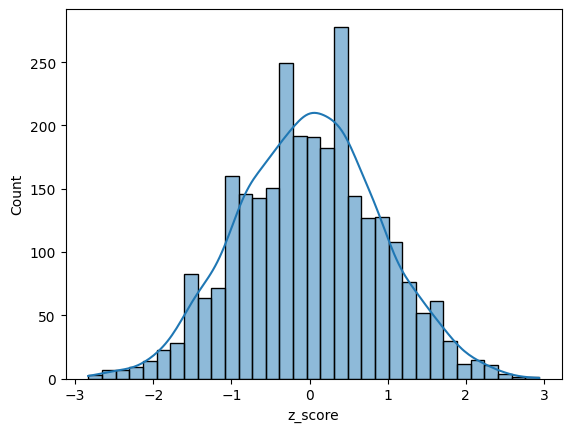

In [18]:
sns.histplot(df_no_outliers.z_score, kde = True )